In [3]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import torch
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_dataset, FEATURE_NAMES

# Load all 34 stocks
feed = DataFeed.from_dir('data/egx')
print(f"Universe: {feed.n_assets} assets")
print(f"Period: {feed.dates[0].date()} → {feed.dates[-1].date()}")
print(f"Days: {feed.n_days}")


Universe: 34 assets
Period: 2021-10-20 → 2026-07-30
Days: 1159


In [5]:
# Pick COMI (index 8 in the sorted list)
symbol = 'COMI'
asset_idx = feed.symbols.index(symbol)

# Build dataset: X = features, y = next-day return
X, y = build_dataset(feed, asset_idx)

print(f"Stock: {symbol}")
print(f"Features: {X.shape[1]} → {FEATURE_NAMES}")
print(f"Samples: {X.shape[0]} rows (after dropping NaN)")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print()



Stock: COMI
Features: 9 → ['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility', 'macd_hist', 'return_5d', 'return_10d', 'volume_ratio']
Samples: 1125 rows (after dropping NaN)
X shape: (1125, 9)
y shape: (1125,)



In [6]:
# Split by TIME: first 70% = train, last 30% = test
split = int(len(X) * 0.7)

X_train, y_train = X[:split], y[:split]
X_test,  y_test  = X[split:], y[split:]

print(f"Train: {len(X_train)} samples (first 70% of time)")
print(f"Test:  {len(X_test)} samples (last 30% of time)")
print()
print(f"Train period: row 0 → {split-1}")
print(f"Test period:  row {split} → {len(X)-1}")


Train: 787 samples (first 70% of time)
Test:  338 samples (last 30% of time)

Train period: row 0 → 786
Test period:  row 787 → 1124


In [10]:
from tradinglab.models import MLP
from tradinglab.ml import train_model
model=MLP(n_features=9,hidden=32)
print("Model architecture:")
print(model)
print()
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print()

# Train for 200 epochs
print("Training...")
history = train_model(model, X_train, y_train, X_test, y_test, epochs=200, lr=0.001)
print(f"Final train loss: {history['train'][-1]:.6f}")
print(f"Final test loss:  {history['test'][-1]:.6f}")


Model architecture:
MLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 353

Training...
Final train loss: 0.000471
Final test loss:  0.000722


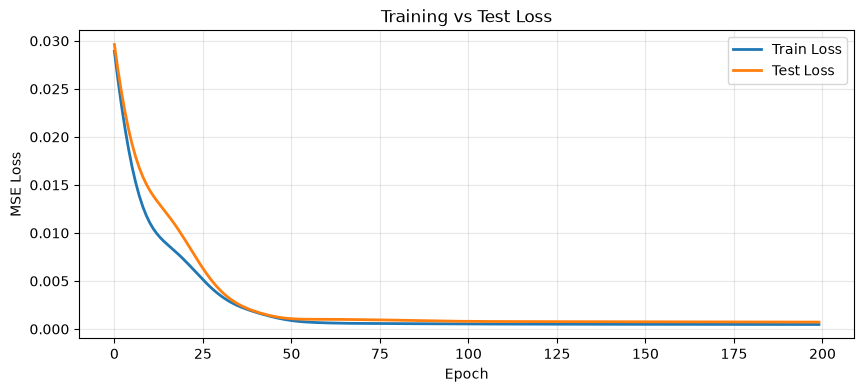

In [11]:
# Plot train vs test loss over epochs
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train Loss', linewidth=2)
plt.plot(history['test'], label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Test Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


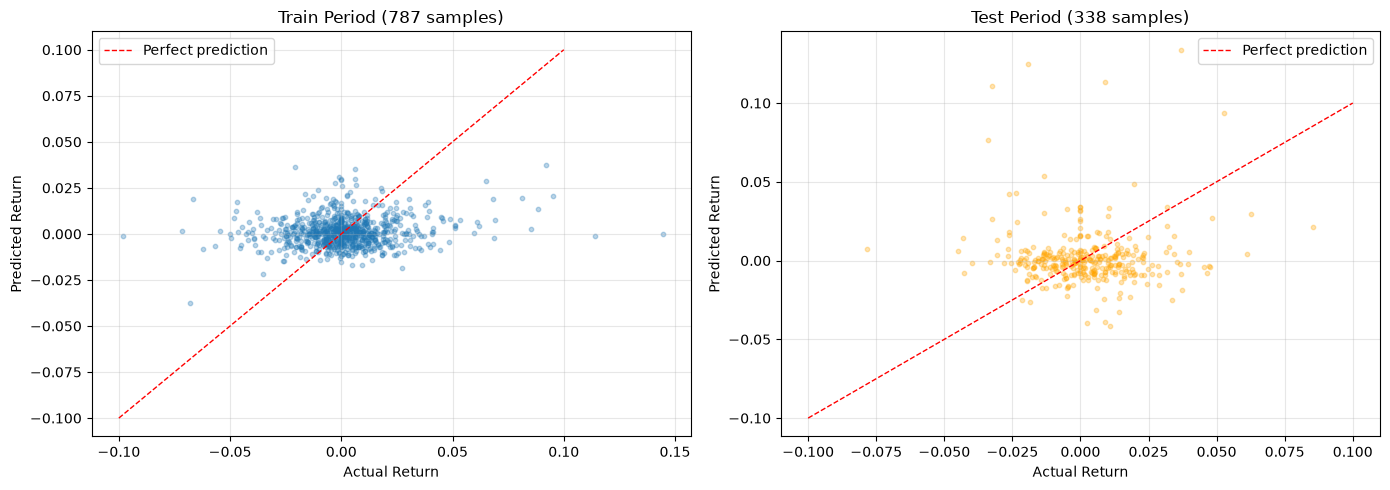

In [12]:
from tradinglab.ml import predict

# Get predictions
y_train_pred = predict(model, X_train)
y_test_pred  = predict(model, X_test)

# Plot predicted vs actual for both periods
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Train period
ax1.scatter(y_train, y_train_pred, alpha=0.3, s=10)
ax1.plot([-0.1, 0.1], [-0.1, 0.1], 'r--', linewidth=1, label='Perfect prediction')
ax1.set_xlabel('Actual Return')
ax1.set_ylabel('Predicted Return')
ax1.set_title(f'Train Period ({len(y_train)} samples)')
ax1.legend()
ax1.grid(alpha=0.3)

# Test period
ax2.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange')
ax2.plot([-0.1, 0.1], [-0.1, 0.1], 'r--', linewidth=1, label='Perfect prediction')
ax2.set_xlabel('Actual Return')
ax2.set_ylabel('Predicted Return')
ax2.set_title(f'Test Period ({len(y_test)} samples)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# Directional accuracy: did the model predict UP vs DOWN correctly?
def directional_accuracy(y_true, y_pred):
    """Fraction of days the model got the direction right (positive vs negative)."""
    true_direction = np.sign(y_true)        # +1 if return > 0, -1 if < 0, 0 if = 0
    pred_direction = np.sign(y_pred)
    accuracy = np.mean(true_direction == pred_direction)
    return accuracy

train_acc = directional_accuracy(y_train, y_train_pred)
test_acc  = directional_accuracy(y_test, y_test_pred)

print(f"Directional Accuracy (train): {train_acc:.1%}")
print(f"Directional Accuracy (test):  {test_acc:.1%}")
print()
print("(50% is random guessing. Above 50% is real edge.)")


Directional Accuracy (train): 47.5%
Directional Accuracy (test):  46.2%

(50% is random guessing. Above 50% is real edge.)


In [14]:
from tradinglab.models import DeepMLP

# Define 4 models to compare
configs = [
    {"name": "Small (2L, 16H)",    "hidden": 16, "n_layers": 2},
    {"name": "Medium (2L, 32H)",   "hidden": 32, "n_layers": 2},
    {"name": "Large (3L, 64H)",    "hidden": 64, "n_layers": 3},
    {"name": "Very Large (4L, 128H)", "hidden": 128, "n_layers": 4},
]

results = []

for config in configs:
    print(f"\n{'='*50}")
    print(f"Training: {config['name']}")
    print(f"{'='*50}")

    # Build model
    model = DeepMLP(n_features=9, hidden=config['hidden'], n_hidden_layers=config['n_layers'])
    print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

    # Train
    history = train_model(model, X_train, y_train, X_test, y_test, epochs=200, lr=0.001)

    # Predict
    y_train_pred = predict(model, X_train)
    y_test_pred  = predict(model, X_test)

    # Metrics
    train_loss = history['train'][-1]
    test_loss  = history['test'][-1]
    test_acc   = directional_accuracy(y_test, y_test_pred)

    print(f"Train loss: {train_loss:.6f}")
    print(f"Test loss:  {test_loss:.6f}")
    print(f"Test directional accuracy: {test_acc:.1%}")

    results.append({
        "name": config['name'],
        "params": sum(p.numel() for p in model.parameters()),
        "train_loss": train_loss,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "history": history,
    })

print(f"\n{'='*50}")
print("SUMMARY")
print(f"{'='*50}")
for r in results:
    print(f"{r['name']:<25s}  params={r['params']:>6d}  train={r['train_loss']:.6f}  test={r['test_loss']:.6f}  acc={r['test_acc']:.1%}")



Training: Small (2L, 16H)
Parameters: 449
Train loss: 0.000457
Test loss:  0.000430
Test directional accuracy: 49.7%

Training: Medium (2L, 32H)
Parameters: 1409
Train loss: 0.000409
Test loss:  0.000417
Test directional accuracy: 48.2%

Training: Large (3L, 64H)
Parameters: 9025
Train loss: 0.000372
Test loss:  0.000516
Test directional accuracy: 48.2%

Training: Very Large (4L, 128H)
Parameters: 50945
Train loss: 0.000349
Test loss:  0.000528
Test directional accuracy: 48.5%

SUMMARY
Small (2L, 16H)            params=   449  train=0.000457  test=0.000430  acc=49.7%
Medium (2L, 32H)           params=  1409  train=0.000409  test=0.000417  acc=48.2%
Large (3L, 64H)            params=  9025  train=0.000372  test=0.000516  acc=48.2%
Very Large (4L, 128H)      params= 50945  train=0.000349  test=0.000528  acc=48.5%
